## Question 3

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('spambase/spambase.data', header=None)

columns = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam'
]

df.columns = columns

X = df.drop(columns="spam")
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

## Question 3.1

In [6]:
n_estimators_list = [10, 50, 100, 500]

results_ada = []

for T in n_estimators_list:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=7),
        n_estimators=T,
        random_state=1
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    results_ada.append({
        "T": T,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob)
    })

results_ada_df = pd.DataFrame(results_ada)
print(results_ada_df)

     T  train_accuracy  test_accuracy  train_f1   test_f1  train_auc  test_auc
0   10        0.988986       0.939183  0.985926  0.921171   0.999547  0.980799
1   50        0.999710       0.957428  0.999633  0.945495   1.000000  0.988103
2  100        0.999710       0.960904  0.999633  0.950276   1.000000  0.988448
3  500        0.999710       0.960904  0.999633  0.950166   1.000000  0.988521


## Analysis

With each increase in T, the test metrics continue to improve all the way up to 500

## Question 3.2

In [ ]:
rf_metrics = """     
     T  train_accuracy  test_accuracy  train_f1   test_f1  train_auc  test_auc
0   10        0.997101       0.947003  0.996329  0.930917   0.999948  0.982550
1   50        0.999710       0.965248  0.999633  0.954853   0.999999  0.988818
2  100        0.999710       0.966985  0.999633  0.957494   0.999999  0.989244
3  500        0.999710       0.966116  0.999633  0.956130   1.000000  0.988754 """

ada_metrics = """     
     T  train_accuracy  test_accuracy  train_f1   test_f1  train_auc  test_auc
0   10        0.988986       0.939183  0.985926  0.921171   0.999547  0.980799
1   50        0.999710       0.957428  0.999633  0.945495   1.000000  0.988103
2  100        0.999710       0.960904  0.999633  0.950276   1.000000  0.988448
3  500        0.999710       0.960904  0.999633  0.950166   1.000000  0.988521 """


## Analysis

Looking at one metric at a time, the train accuracy produces very similar results, converging to the exact same value. Test accuracy reaches a slightly higher max in the Random Forest, getting to .967 as opposed to .960. Train F1 again is very similar converging to the same value. Test F1 again reaches a slightly higher max in Random Forest, reaching .957 as opposed to .950 from the AdaBoost model. Train AUC is almost the same, although AdaBoost does reach 1.0 at only 50 trees rather than the 500 it takes Random Forest to. Test AUC is practically identical for both, staying right at 0.98 for all values of T for both models. Overall, it seems that RandomForest reaches some higher maximums than AdaBoost making it a better model in this situation.

## Question 3.3

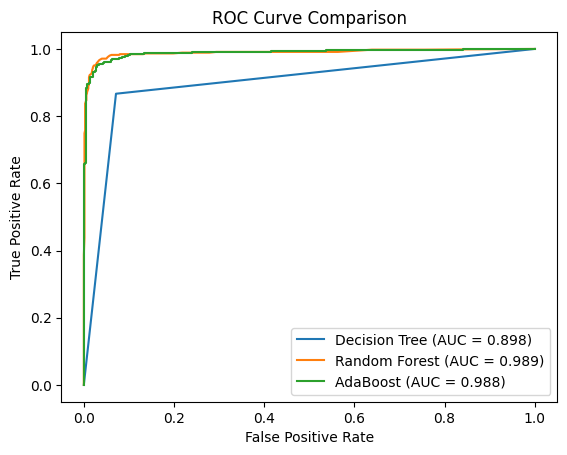

In [10]:
tree = DecisionTreeClassifier(random_state=1)
rf_100 = RandomForestClassifier(n_estimators=100, random_state=1)
ada_100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=7),
    n_estimators=100,
    random_state=1
)


tree.fit(X_train, y_train)
rf_100.fit(X_train, y_train)
ada_100.fit(X_train, y_train)


tree_prob = tree.predict_proba(X_test)[:, 1]
rf_prob = rf_100.predict_proba(X_test)[:, 1]
ada_prob = ada_100.predict_proba(X_test)[:, 1]


fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)


auc_tree = auc(fpr_tree, tpr_tree)
auc_rf = auc(fpr_rf, tpr_rf)
auc_ada = auc(fpr_ada, tpr_ada)

# Plot
plt.figure()
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {auc_ada:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()